In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import cns.data_utils as cdu
import cns

In [3]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6) })	

In [ ]:
full = {
    "PCAWG" : cdu.load_samples_file("PCAWG_samples_align.tsv"),
    "TCGA_hg19": cdu.load_samples_file("TCGA_hg19_samples_align.tsv"),
    "TRACERx": cdu.load_samples_file("TRACERx_samples_align.tsv"),
}
gaps = {
    "PCAWG" : cdu.load_samples_file("PCAWG_samples.tsv"),
    "TCGA_hg19": cdu.load_samples_file("TCGA_hg19_samples.tsv"),
    "TRACERx": cdu.load_samples_file("TRACERx_samples.tsv"),	
}
colors = {"PCAWG": "C0", "TCGA_hg19": "C1", "TRACERx": "C2", "combined": "gray"}


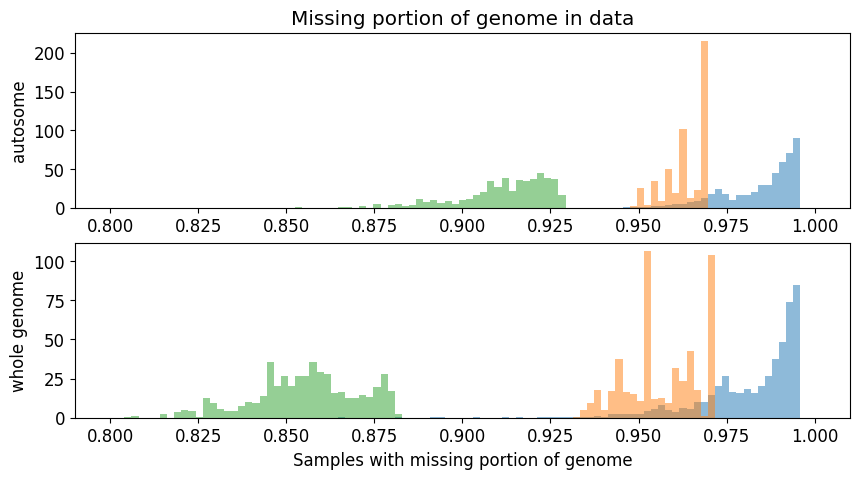

In [5]:
fig, axs = plt.subplots(2, figsize=(10, 5))
bins = np.linspace(.80, 1, 100)
yaxes = ["autosome", "whole genome"]
features = ["cover_any_aut", "cover_any_all"]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(full[k][features[j]], density=True, bins=bins, alpha=0.5, color=colors[k], label=k)
    axs[j].set_ylabel(yaxes[j])
axs[0].set_title("Missing portion of genome in data")
axs[1].set_xlabel("Samples with missing portion of genome")
cdu.save_cns_fig("coverage_all_vs_aut")

PCAWG whole genome (autosomes only) 0.9846808838809696
TCGA_hg19 whole genome (autosomes only) 0.9638779450595134
TRACERx whole genome (autosomes only) 0.9118084721485119
PCAWG with gap mask applied 0.9962391263522663
TCGA_hg19 with gap mask applied 0.9989471019390798
TRACERx with gap mask applied 0.9739585448682551
PCAWG samples below 0.85 1
TCGA_hg19 samples below 0.85 0
TRACERx samples below 0.85 0


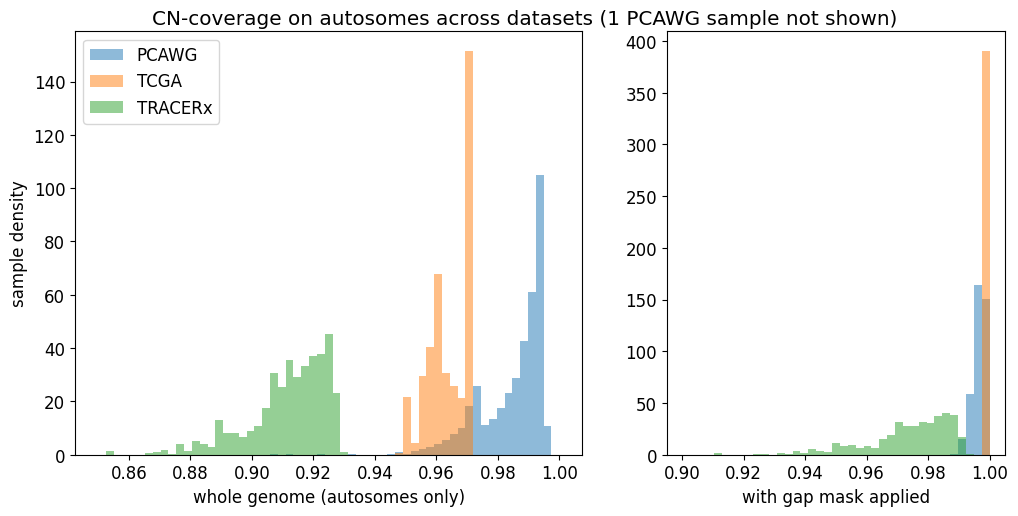

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={'width_ratios': [3, 2]})
bins = [np.linspace(.85, 1, 60), np.linspace(.90, 1, 40)]
xaxes = ["whole genome (autosomes only)", "with gap mask applied"]
source = [full, gaps]
for j in range(2):
    for i, (k, v) in enumerate(full.items()):
        axs[j].hist(source[j][k]["cover_any_aut"], density=True, bins=bins[j], alpha=0.5, color=colors[k], label=k.split("_")[0])
        print(k, xaxes[j], np.mean(source[j][k]["cover_any_aut"].mean()))
    axs[j].set_xlabel(xaxes[j])
axs[0].legend()
axs[0].set_ylabel("sample density")
plt.suptitle("CN-coverage on autosomes across datasets (1 PCAWG sample not shown)", y=.92)
cdu.save_cns_fig("coverage_whole_vs_gap", fig)
# samples below 0.85
for k, v in full.items():
	print(k, "samples below 0.85", np.sum(full[k]["cover_any_aut"] < 0.85))

In [ ]:
select_regs = cns.make_segments("whole")
remove_regs = cns.make_segments("gaps")

select_sizes = cns.get_norm_sizes(select_regs)
print(select_sizes)
remove_sizes = cns.get_norm_sizes(remove_regs)
print(remove_sizes)

for k, v in select_sizes.items():
	print(k, remove_sizes[k] / select_sizes[k])

{'sexXX': 155270560, 'aut': 2881033286, 'sexXY': 214644126, 'allXX': 3036303846, 'allXY': 3095677412}
{'sexXX': 4170000, 'aut': 196454806, 'sexXY': 37890000, 'allXX': 200624806, 'allXY': 234344806}
sexXX 0.026856346753692393
aut 0.0681890094622114
sexXY 0.17652474682675454
allXX 0.06607533902257554
allXY 0.07570065443240052


# Find regions of TRACERx with missing data

In [ ]:
tracerx_cns_df = cdu.load_cns_file("TRACERx_cns_align.tsv")
tracerx_samples_df = cdu.load_samples_file("TRACERx_samples.tsv")

In [9]:
hg19_segs = cns.main_segment(select_regs, remove_regs)
filtered_cns_df = cns.main_aggregate(tracerx_cns_df, hg19_segs, "none", print_info=True)	
filtered_cns_df["nan"] = cns.calc_nan_cols(filtered_cns_df).astype(int)
filtered_cns_df.head()

Aggregated into 1377475 CNS.                                        


,sample_id,chrom,start,end,major_cn,minor_cn,name,nan
0,CRUK0001_SU_T1-R1,chr1,10000,177417,NaN,NaN,chr1_0,1
1,CRUK0001_SU_T1-R1,chr1,227417,267719,NaN,NaN,chr1_1,1
2,CRUK0001_SU_T1-R1,chr1,317719,471368,NaN,NaN,chr1_2,1
3,CRUK0001_SU_T1-R1,chr1,521368,762272,NaN,NaN,chr1_3,1
4,CRUK0001_SU_T1-R1,chr1,762272,2634220,2.0,2.0,chr1_3,0


In [10]:
MB_segs = cns.main_segment(select_regs, remove_regs, split_size=3000000)
aggregated_df = cns.main_aggregate(filtered_cns_df, MB_segs, how="mean", cn_columns=["nan"], print_info=True)
grouped_df = cns.group_samples(aggregated_df, cn_columns=["nan"])

Aggregated into 1739780 CNS.                                        


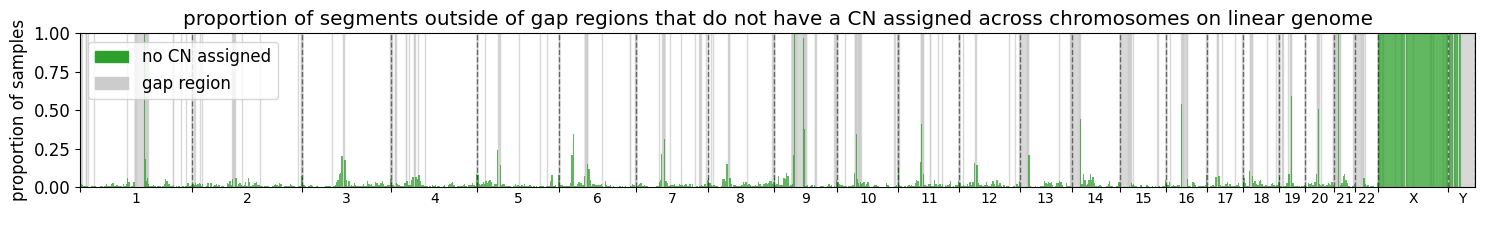

In [ ]:
fig, ax = plt.subplots(figsize=(18, 2), dpi=100)
cns.plot_gaps(ax, alpha=.75, color="#CCCCCC")
cns.plot_bars(ax, grouped_df, cn_column="nan", color="C2", alpha=0.75, size=0)
cns.plot_x_lines(ax)
cns.plot_x_ticks(ax)
ax.set_ylim(0, 1)

ax.set_ylabel("proportion of samples")
ax.set_title("proportion of segments outside of gap regions that do not have a CN assigned across chromosomes on linear genome")
# add legend with two square colors, blue and gray

cn_assigned_patch = mpatches.Patch(color='C2', label='no CN assigned')
no_cn_assigned_patch = mpatches.Patch(color='#CCCCCC', label='gap region')
ax.legend(handles=[cn_assigned_patch, no_cn_assigned_patch], loc="upper left")

cdu.save_cns_fig("TRACERx_segments_no_cn")

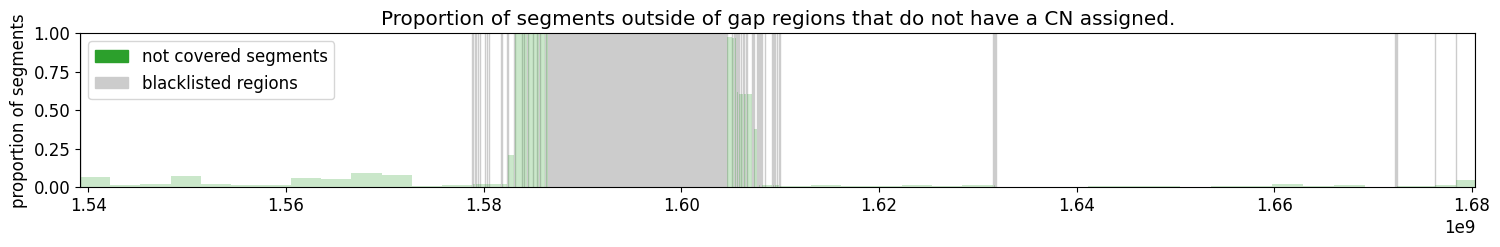

In [12]:
ig, ax = plt.subplots(figsize=(18, 2))
cns.plot_gaps(ax, alpha=1, color="#CCCCCC")
cns.plot_bars(ax, grouped_df.query("chrom == 'chr9'"), cn_column="nan", color="C2", alpha=.25, size=0)
ax.set_xlim(cns.x_limits(grouped_df.query("chrom == 'chr9'")))
ax.set_ylim(0, 1)
ax.set_ylabel("proportion of segments")
ax.set_title("Proportion of segments outside of gap regions that do not have a CN assigned.")
# add legend with two square colors, blue and gray
ax.legend(["no CN assigned", "gap region"], loc="upper right")

cn_assigned_patch = mpatches.Patch(color='C2', label='not covered segments')
no_cn_assigned_patch = mpatches.Patch(color='#CCCCCC', label='blacklisted regions')
ax.legend(handles=[cn_assigned_patch, no_cn_assigned_patch], loc="upper left")

cdu.save_cns_fig("TRACERx_segments_no_cn_chr9")